In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import figure
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import numpy as np
import os
import joblib

In [2]:
PROCESSED_DIR = "../dataset/processed"

if not os.path.exists(PROCESSED_DIR):
    raise FileNotFoundError(f"Directory {PROCESSED_DIR} not found. Please run preprocess_pipeline.ipynb first.")

print("Loading X data (Features)...")
X_train = pd.read_parquet(f"{PROCESSED_DIR}/X_train.parquet")
X_val = pd.read_parquet(f"{PROCESSED_DIR}/X_val.parquet")
X_test = pd.read_parquet(f"{PROCESSED_DIR}/X_test.parquet")

print("Loading y data (Labels)...")
y_train = pd.read_parquet(f"{PROCESSED_DIR}/y_train.parquet")['label']
y_val = pd.read_parquet(f"{PROCESSED_DIR}/y_val.parquet")['label']
y_test = pd.read_parquet(f"{PROCESSED_DIR}/y_test.parquet")['label']

print("\n--- Data Shapes ---")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

Loading X data (Features)...
Loading y data (Labels)...

--- Data Shapes ---
X_train: (432395, 162), y_train: (432395,)
X_val:   (54049, 162), y_val:   (54049,)
X_test:  (54050, 162), y_test:  (54050,)


In [3]:
print("Loading Preprocessing Artifacts...")

# Load Label Encoder
le = joblib.load(f"{PROCESSED_DIR}/label_encoder.joblib")
print("\nLabel mapping (class -> encoded):")
for cls in le.classes_:
    print(f"  {cls} -> {int(le.transform([cls])[0])}")

# Load Preprocessing Info (Zero variance cols and High correlation cols that were dropped)
preprocessing_info = joblib.load(f"{PROCESSED_DIR}/preprocessing_info.joblib")
print("\nPreprocessing Info:")
print(f"  Zero-variance columns dropped:     {len(preprocessing_info['zero_var_cols'])}")
print(f"  Highly-correlated columns dropped: {len(preprocessing_info['high_corr_cols'])}")
print(f"  Final feature columns count:       {len(preprocessing_info['feature_columns'])}")

Loading Preprocessing Artifacts...

Label mapping (class -> encoded):
  Attack -> 0
  Benign -> 1
  Suspicious -> 2

Preprocessing Info:
  Zero-variance columns dropped:     3
  Highly-correlated columns dropped: 152
  Final feature columns count:       162


In [4]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_sample_weight

tune_xgb = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    tree_method='hist',
    device='cuda', # Will fallback or you can change to cpu if needed
    n_jobs=-1,
    random_state=42
)

param_distributions = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 6, 9],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0]
}

# Calculate sample weights to explicitly handle class imbalance during CV
sample_weights_train = compute_sample_weight('balanced', y_train)

print("[XGBoost] Starting RandomizedSearchCV...")
search = RandomizedSearchCV(tune_xgb, param_distributions, n_iter=3, scoring='f1_macro', cv=3, random_state=42, n_jobs=1, verbose=2)

# Pass sample weights to fit via fit_params
search.fit(X_train, y_train, sample_weight=sample_weights_train)

model = search.best_estimator_
print(f"[XGBoost] Best Hyperparameters: {search.best_params_}")

val_pred = model.predict(X_val)
print(f"[Val] Macro F1: {f1_score(y_val, val_pred, average='macro'):.4f}")

[XGBoost] Starting RandomizedSearchCV...
Fitting 3 folds for each of 3 candidates, totalling 9 fits


/home/kenneth/Documents/College/MachineLearning/Project-Machine-Learning/ml_network/lib64/python3.14/site-packages/xgboost/core.py:751: UserWarning: [23:15:26] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END learning_rate=0.05, max_depth=3, n_estimators=300, subsample=0.6; total time=   5.2s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=300, subsample=0.6; total time=   4.2s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=300, subsample=0.6; total time=   4.3s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.6; total time=   2.0s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.6; total time=   2.2s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.6; total time=   2.1s
[CV] END learning_rate=0.01, max_depth=9, n_estimators=300, subsample=0.8; total time=  15.5s
[CV] END learning_rate=0.01, max_depth=9, n_estimators=300, subsample=0.8; total time=  14.7s
[CV] END learning_rate=0.01, max_depth=9, n_estimators=300, subsample=0.8; total time=  15.7s
[XGBoost] Best Hyperparameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.01}
[Val] Macro F1: 0.8507



=== Classification Report ===
              precision    recall  f1-score   support

      Attack     0.9757    0.8937    0.9329     17044
      Benign     0.9928    0.9655    0.9789     34918
  Suspicious     0.4566    0.9794    0.6228      2088

    accuracy                         0.9434     54050
   macro avg     0.8083    0.9462    0.8449     54050
weighted avg     0.9667    0.9434    0.9507     54050



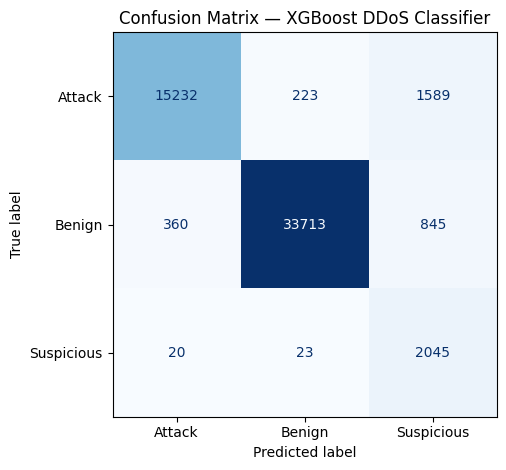

In [5]:
y_pred = model.predict(X_test)
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test)

print("\n=== Classification Report ===")
print(classification_report(y_test_labels, y_pred_labels, digits=4))

cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — XGBoost DDoS Classifier")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [6]:
f1_macro = f1_score(y_test_labels, y_pred_labels, average="macro")
f1_weighted = f1_score(y_test_labels, y_pred_labels, average="weighted")

print(f"F1 (macro): {f1_macro:.4f}")
print(f"F1 (weighted): {f1_weighted:.4f}")

F1 (macro): 0.8449
F1 (weighted): 0.9507


In [7]:
import pickle

with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("[Output] Trained model saved to 'xgboost_model.pkl'")

[Output] Trained model saved to 'xgboost_model.pkl'


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

try:
    y_true_for_metrics = y_test_labels
    y_pred_for_metrics = y_pred_labels
except NameError:
    y_true_for_metrics = y_test
    if 'y_pred_encoded' in locals():
        y_pred_for_metrics = y_pred_encoded
    elif 'y_pred' in locals():
        y_pred_for_metrics = y_pred

accuracy = accuracy_score(y_true_for_metrics, y_pred_for_metrics)
precision = precision_score(y_true_for_metrics, y_pred_for_metrics, average='weighted')
recall = recall_score(y_true_for_metrics, y_pred_for_metrics, average='weighted')
f1 = f1_score(y_true_for_metrics, y_pred_for_metrics, average='weighted')

try:
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
        roc_auc_str = f"{roc_auc:.4f}"
    else:
        # Some models like LinearSVC don't have predict_proba but might have decision_function
        if hasattr(model, 'decision_function'):
            y_pred_decision = model.decision_function(X_test)
            roc_auc = roc_auc_score(y_test, y_pred_decision, multi_class='ovr', average='weighted')
            roc_auc_str = f"{roc_auc:.4f}"
        else:
            roc_auc_str = "N/A (predict_proba not available)"
except Exception as e:
    roc_auc_str = f"N/A ({e})"

print("--- Classification Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}\n")
print("--- ROC-AUC ---")
print(f"ROC-AUC Score: {roc_auc_str}")


--- Classification Metrics ---
Accuracy:  0.9434
Precision: 0.9667
Recall:    0.9434
F1-score:  0.9507

--- ROC-AUC ---
ROC-AUC Score: 0.9976
